### Calculating the QM solution of the reaction between $OH^-$ and $CH_3Cl$

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf
from pyscf.geomopt.geometric_solver import optimize
import pickle

In [2]:
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf_with_solvent(mol):

    mf = scf.RHF(mol)

    # Add implicit solvent using ddCOSMO
    # mf = mf.ddCOSMO()

    # Water dielectric constant
    # mf.with_solvent.eps = 78.3553

    return mf
    
def optimize_at_distance(mol, distance):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf_with_solvent(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt"
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf_with_solvent(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )


In [3]:
initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890
"""

In [4]:
symbols = [
    "O",
    "H",
    "C",
    "Cl",
    "H",
    "H",
    "H"
]

In [5]:
mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

In [6]:
ndistances = 20
distances = np.linspace(3.0, 1.2, ndistances)

print("Number of steps:", len(distances))
print("Starting distance:", distances[0])
print("Final distance:", distances[-1])

Number of steps: 20
Starting distance: 3.0
Final distance: 1.2


In [7]:
os.makedirs("xyz_frames", exist_ok=True)
for f in glob.glob("xyz_frames/frame_*.xyz"):
    os.remove(f)

print("XYZ folder cleared.")

XYZ folder cleared.


In [9]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []

current_mol = mol

In [11]:
for i, distance in enumerate(distances):

    print("=" * 70)
    print(f"FRAME {i+1}/"+str(ndistances))
    print(f"Target C-O distance: {distance:.6f} Å")

    # ------------------------------------------------
    # 1. Get previous optimized geometry
    # ------------------------------------------------

    current_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    # ------------------------------------------------
    # 2. Move OH- to the next reaction-coordinate value
    # ------------------------------------------------

    current_coords = move_oh_to_distance(
        current_coords,
        distance
    )

    # ------------------------------------------------
    # 3. Rebuild PySCF molecule
    # ------------------------------------------------

    current_mol = build_molecule(
        current_coords
    )

    # ------------------------------------------------
    # 4. Constrained solvated optimization
    # ------------------------------------------------

    current_mol, energy = optimize_at_distance(
        current_mol,
        distance
    )
    mf = scf.RHF(current_mol)
    energy = mf.kernel()
    
    # ------------------------------------------------
    # 5. Store optimized molecule, energy, and mean field
    # ------------------------------------------------

    optimized_molecules.append(current_mol)
    energies.append(energy)
    mean_field_objects.append(mf)
    
    # ------------------------------------------------
    # 6. Calculate actual C-O distance
    # ------------------------------------------------

    optimized_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    actual_distance = np.linalg.norm(
        optimized_coords[0] -
        optimized_coords[2]
    )

    actual_distances.append(
        actual_distance
    )

    # ------------------------------------------------
    # 7. Save XYZ
    # ------------------------------------------------

    filename = (
        f"xyz_frames/frame_{i:03d}.xyz"
    )

    write_xyz(
        current_mol,
        filename,
        actual_distance
    )

    # ------------------------------------------------
    # 8. Report
    # ------------------------------------------------

    print(
        f"Actual C-O: "
        f"{actual_distance:.6f} Å"
    )

    print(
        f"Energy: "
        f"{energy:.10f} Hartree"
    )

    print(
        f"Saved: {filename}"
    )

geometric-optimize called with the following command line:
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/ipykernel_launcher.py -f /home/chemistry/.local/share/jupyter/runtime/kernel-9a951f52-09b8-47a3-a69c-8f28297f9823.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **

FRAME 1/20
Target C-O distance: 3.000000 Å

Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.000000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -3.970000   0.000000   0.000000    0.000000  0.000000  0.000000
   C   0.000000   0.000000   0.000000    0.000000  0.000000  0.000000
  Cl   1.780000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -0.630000   0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000  -0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000   0.000000  -0.890000    0.000000  0.000000  0.000000

WARN: Mole.unit (Angstrom) is changed to Bohr

converged SCF energy = -574.3374280577
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O    -0.0121572510     0.0000000000    -0.0018561992
1 H    -0.0004407791    -0.0000000000    -0.0006339463
2 C     0.1137277187     0.0000000000    -0

Step    0 : Gradient = 5.282e-02/9.287e-02 (rms/max) Energy = -574.3374280577
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 3.46752e-01 3.47392e-01 5.01282e-01



Geometry optimization cycle 2
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.025533  -0.000000   0.009343   -0.025533 -0.000000  0.009343
   H  -3.990991   0.000000   0.002801   -0.020991  0.000000  0.002801
   C  -0.027512  -0.000000   0.050466   -0.027512 -0.000000  0.050466
  Cl   1.754677   0.000000   0.016289   -0.025323  0.000000  0.016289
   H  -0.578000   0.794813   0.580392    0.052000  0.164813 -0.049608
   H  -0.578000  -0.794813   0.580392    0.052000 -0.164813 -0.049608
   H  -0.564855  -0.000000  -0.887899    0.065145 -0.000000  0.002101
converged SCF energy = -574.377429061093
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O    -0.0154500398    -0.0000000000    -0.0006171295
1 H     0.0052859221    -0.0000000000    -0.0001294816
2 C     0.1079423189     0.0000000000    -0.0203280110
3 Cl    -0.0159189133    -0.0000000000    -0.0016448160
4 H    -0.0308858950 

Step    1 : Displace = 1.025e-01/1.768e-01 (rms/max) Trust = 1.000e-01 (=) Grad_T = 3.954e-02/8.920e-02 (rms/max) E (change) = -574.3774290611 (-4.000e-02) Quality = 0.909
Constraint                         Current      Target       Diff.
Distance 1-3                       2.99830     3.00000    -0.00170
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 3.46752e-01 3.91340e-01 5.01067e-01


...


Geometry optimization cycle 8
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.194552  -0.000276   0.480364    0.000946 -0.000000  0.000103
   H  -0.611151  -0.001273   1.250629    0.001282  0.000000 -0.000124
   C  -0.721701   0.001796  -0.622545   -0.000116  0.000000 -0.000352
  Cl   1.075540  -0.002827   2.678126   -0.000430 -0.000003  0.002500
   H  -0.085791   0.869195  -0.877960   -0.000431 -0.000033 -0.001214
   H  -0.084926  -0.864113  -0.880844   -0.000432  0.000036 -0.001215
   H  -1.495507   0.002701  -1.398634   -0.000819 -0.000000  0.000303
converged SCF energy = -574.490221157294
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.1092212440     0.0004784025    -0.2547332819
1 H    -0.0000285725    -0.0000001367     0.0000761161
2 C    -0.1091808589    -0.0004783704     0.2547186737
3 Cl     0.0000007892     0.0000000286    -0.0000214513
4 H    -0.0000093109 

Step    7 : Displace = 1.374e-03/2.563e-03 (rms/max) Trust = 3.000e-01 (=) Grad_T = 4.440e-05/8.130e-05 (rms/max) E (change) = -574.4902211573 (-2.041e-07) Quality = 1.325
Hessian Eigenvalues: 1.57382e-02 2.30000e-02 3.84418e-02 ... 3.56047e-01 5.52598e-01 1.21962e+00



Geometry optimization cycle 9
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.193962  -0.000276   0.480418    0.000590 -0.000000  0.000054
   H  -0.610125  -0.001272   1.250339    0.001027  0.000000 -0.000290
   C  -0.721810   0.001796  -0.622790   -0.000109  0.000000 -0.000245
  Cl   1.075154  -0.002829   2.679707   -0.000386 -0.000002  0.001581
   H  -0.086060   0.869212  -0.878624   -0.000268  0.000017 -0.000664
   H  -0.085195  -0.864129  -0.881509   -0.000269 -0.000015 -0.000666
   H  -1.496090   0.002701  -1.398403   -0.000583  0.000000  0.000231
converged SCF energy = -574.49022123217
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.1090393468     0.0004784557    -0.2547670594
1 H    -0.0000146660    -0.0000000726     0.0000338110
2 C    -0.1090177977    -0.0004784654     0.2547819557
3 Cl     0.0000025989     0.0000000053    -0.0000043949
4 H    -0.0000073276  

Step    8 : Displace = 8.969e-04/1.643e-03 (rms/max) Trust = 3.000e-01 (=) Grad_T = 2.788e-05/4.314e-05 (rms/max) E (change) = -574.4902212322 (-7.488e-08) Quality = 1.283
Hessian Eigenvalues: 1.57382e-02 2.30000e-02 3.84418e-02 ... 3.56047e-01 5.52598e-01 1.21962e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2016) "Geometry optimization made simple with |#
    #| translation and rotation coordinates", J. Chem, Phys. 144, 214108.     |#
    #| http://dx.doi.org/10.1063/1.4952956                                    |#
    #==========================================================================#
    Time elapsed since start of run_optimizer: 7.289 seconds


converged SCF energy = -574.490221232171
converged SCF energy = -574.490221232171
Actual C-O: 1.200000 Å
Energy: -574.4902212322 Hartree
Saved: xyz_frames/frame_019.xyz


### Visualizing some results

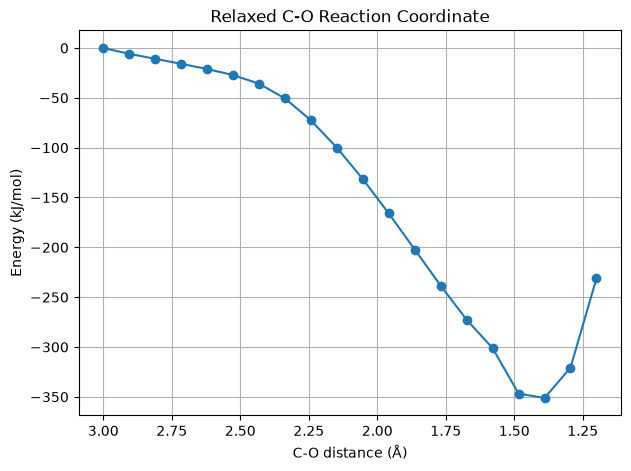

In [12]:
# Looking at the energies
energies_kj=(energies-energies[0])*2626
plt.figure(figsize=(7,5))
plt.plot(actual_distances,energies_kj,marker="o")
plt.gca().invert_xaxis()
xlabel = "C-O distance (Å)"; plt.xlabel(xlabel)
ylabel = "Energy (kJ/mol)"
plt.ylabel(ylabel)
plt.title("Relaxed C-O Reaction Coordinate")
plt.grid(True)
plt.show()

### Saving additional results

In [13]:
# Saves the optimized molecule objects
with open("optimized_mols.pkl", "wb") as f:
    pickle.dump(optimized_molecules, f)

with open("optimized_mfs.pkl", "wb") as f:
    pickle.dump(mean_field_objects, f)
    
# Save the energies as a text file
data = np.array([actual_distances,energies_kj]).T; print(np.shape(data))
np.savetxt('energy.txt',data,header=xlabel+', '+ylabel)

(20, 2)
